# Heart Disease Prediction: Exploratory Data Analysis

This notebook performs an exploratory data analysis (EDA) on the Statlog Heart Disease dataset from the UCI Machine Learning Repository.

The goal of this analysis is to:
- Understand the dataset structure
- Clean and preprocess the data
- Identify relationships between variables
- Visualize key medical indicators
- Build a baseline machine learning model for heart disease prediction

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

sns.set_style("whitegrid")

In [51]:
heart_df = pd.read_csv("https://raw.githubusercontent.com/ashrivastav33/heart-disease-eda-ml/refs/heads/main/data/data.csv")
heart_df.head()

,age,sex,chest-pain,rest-bp,serum-chol,fasting-blood-sugar,electrocardiographic,max-heart-rate,angina,oldpeak,slope,major-vessels,thal,heart-disease
0,70.0,1.0,4.0,130.0,322.0,0.0,2.0,109.0,0.0,2.4,2.0,3.0,3.0,2
1,67.0,0.0,3.0,115.0,564.0,0.0,2.0,160.0,0.0,1.6,2.0,0.0,7.0,1
2,57.0,1.0,2.0,124.0,261.0,0.0,0.0,141.0,0.0,0.3,1.0,0.0,7.0,2
3,64.0,1.0,4.0,128.0,263.0,0.0,0.0,105.0,1.0,0.2,2.0,1.0,7.0,1
4,74.0,0.0,2.0,120.0,269.0,0.0,2.0,121.0,1.0,0.2,1.0,1.0,3.0,1


In [18]:
heart_df.shape
heart_df.info()
heart_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   270 non-null    float64
 1   sex                   270 non-null    float64
 2   chest-pain            270 non-null    float64
 3   rest-bp               270 non-null    float64
 4   serum-chol            270 non-null    float64
 5   fasting-blood-sugar   270 non-null    float64
 6   electrocardiographic  270 non-null    float64
 7   max-heart-rate        270 non-null    float64
 8   angina                270 non-null    float64
 9   oldpeak               270 non-null    float64
 10  slope                 270 non-null    float64
 11  major-vessels         270 non-null    float64
 12  thal                  270 non-null    float64
 13  heart-disease         270 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 29.7 KB


,age,sex,chest-pain,rest-bp,serum-chol,fasting-blood-sugar,electrocardiographic,max-heart-rate,angina,oldpeak,slope,major-vessels,thal,heart-disease
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296,1.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659,0.497827
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000,1.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000,1.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000,1.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000,2.000000


In [20]:
heart_df.isnull().sum()

,0
age,0
sex,0
chest-pain,0
rest-bp,0
serum-chol,0
fasting-blood-sugar,0
electrocardiographic,0
max-heart-rate,0
angina,0
oldpeak,0


As we can see we don't have any duplicates, hence data cleaning is not required

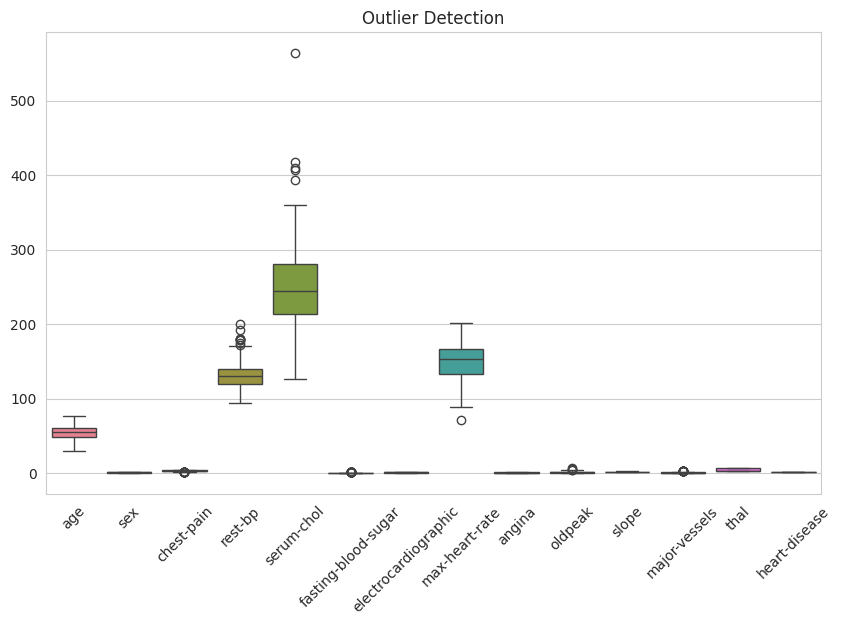

In [29]:
plt.figure(figsize=(10,6))
sns.boxplot(data=heart_df)

plt.title("Outlier Detection")
plt.xticks(rotation=45)  # rotate x-axis labels by 45 degrees

plt.show()

Text(0.5, 1.0, 'Cholesterol Outliers')

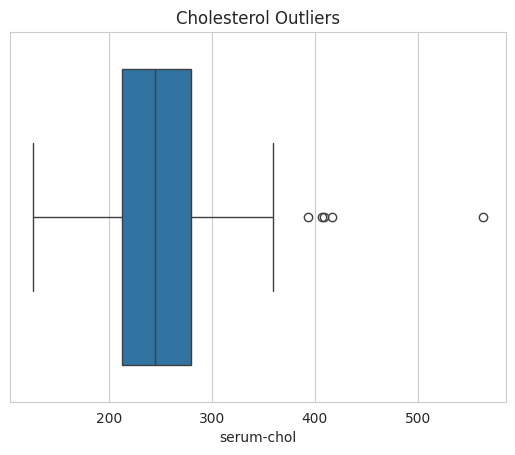

In [31]:
sns.boxplot(x=heart_df['serum-chol'])
plt.title("Cholesterol Outliers")

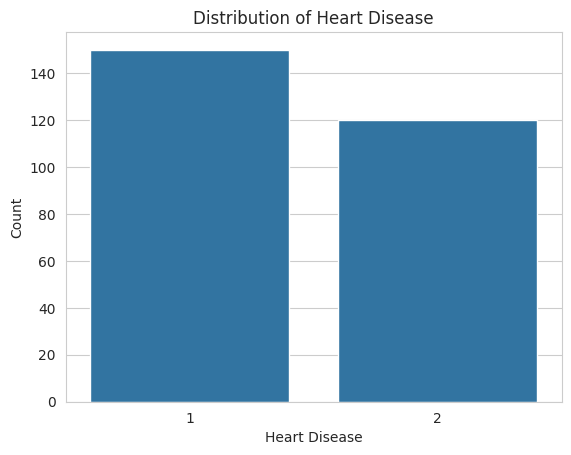

In [56]:
sns.countplot(x='heart-disease', data=heart_df)
plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

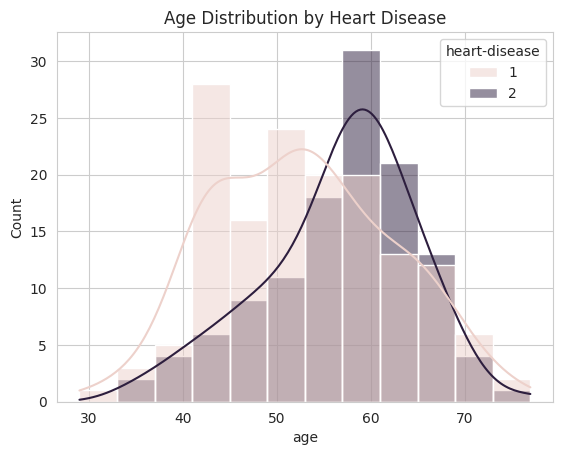

In [39]:
sns.histplot(data=heart_df, x="age", hue="heart-disease", kde=True)
plt.title("Age Distribution by Heart Disease")
plt.show()

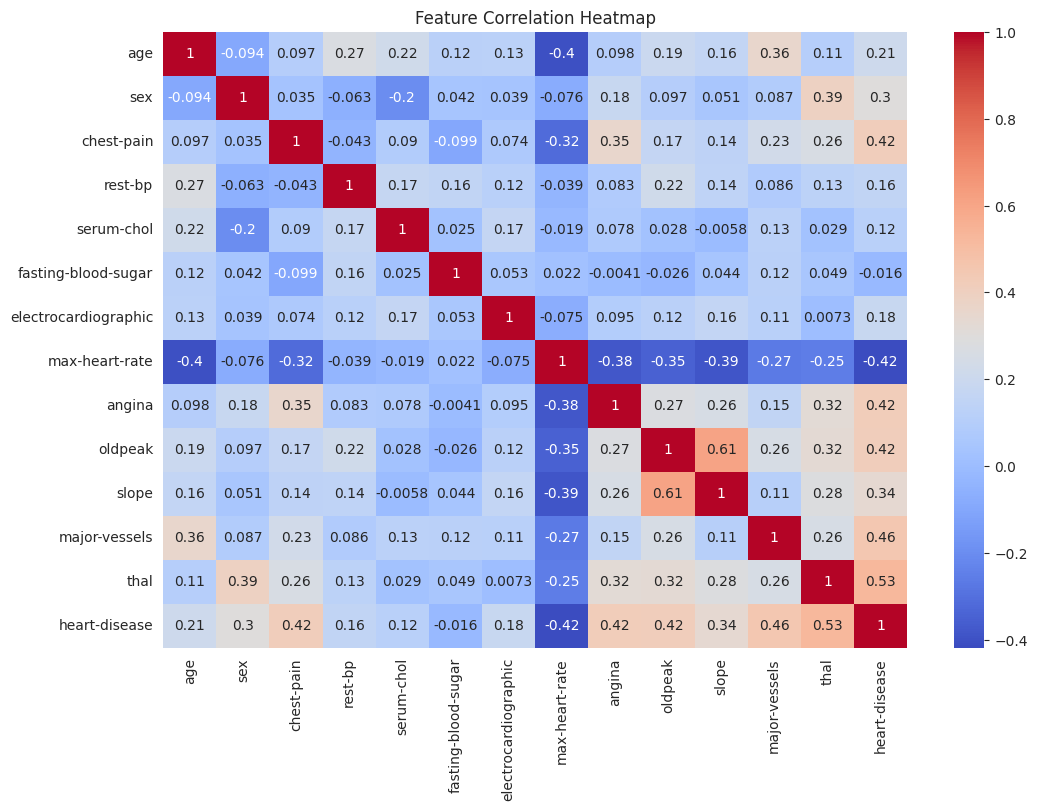

In [40]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

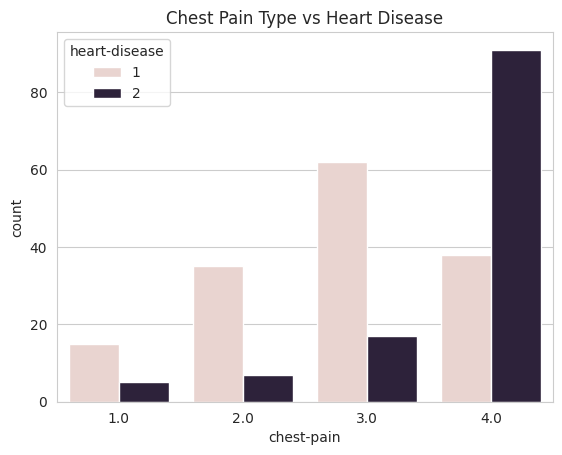

In [44]:
sns.countplot(x='chest-pain', hue='heart-disease', data=heart_df)
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

In [58]:
categorical_cols = ['chest-pain', 'electrocardiographic', 'slope', 'thal']
df = pd.get_dummies(heart_df, columns=categorical_cols, drop_first=True)

X = df.drop('heart-disease', axis=1)
y = df['heart-disease']

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [64]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [65]:
from sklearn.metrics import roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print('Accuracy:', round(accuracy,4))
print('ROC-AUC:', round(roc_auc,4))

Accuracy: 0.8704
ROC-AUC: 0.9466


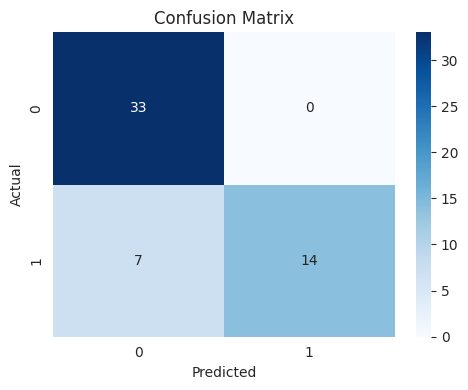

In [67]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

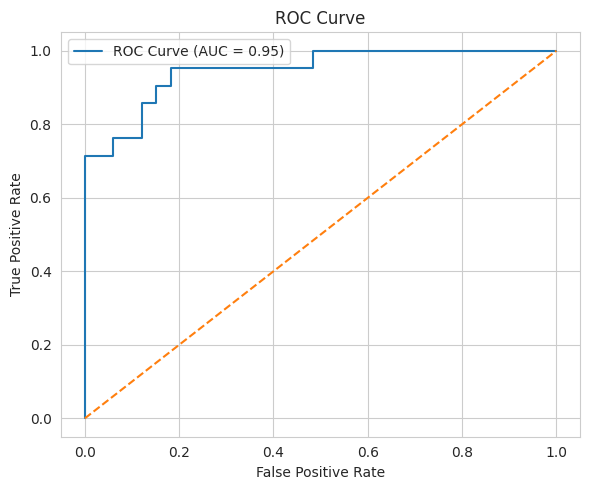

In [70]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=2)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()